In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", 10)
pd.options.display.float_format = '{:.2f}'.format
sns.set()

In [18]:
#1. Get data

df_train = pd.read_csv('fashion-mnist_train.csv')
df_test = pd.read_csv('fashion-mnist_test.csv')
df_train.head()

train = df_train.to_numpy()
test = df_test.to_numpy()
train

array([[2, 0, 0, ..., 0, 0, 0],
       [9, 0, 0, ..., 0, 0, 0],
       [6, 0, 0, ..., 0, 0, 0],
       ...,
       [8, 0, 0, ..., 0, 0, 0],
       [8, 0, 0, ..., 0, 0, 0],
       [7, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [19]:
ms = train.shape[0]
ns = train.shape[1]
mt, nt = test.shape

X_train = train[:,1:ns]
X_train = (X_train.T)/255
y_train = train[:,0]
X_test = test[:,1:nt]
X_test = (X_test.T)/255
y_test = test[:,0]
X_train

# Network architecture
neur1 = 128
neur2 = 64
neur3 = 10  # Output layer

m = X_train.shape[1]   #number of training examples
n = X_train.shape[0]   #number of features (pixels)

In [20]:
# Dataset Distribution

In [21]:
def init_params():
    W1 = np.random.uniform(-0.5, 0.5, (neur1, n))
    b1 = np.random.uniform(-0.5, 0.5, (neur1, 1))
    W2 = np.random.uniform(-0.5, 0.5, (neur2, neur1))
    b2 = np.random.uniform(-0.5, 0.5, (neur2, 1))
    W3 = np.random.uniform(-0.5, 0.5, (neur3, neur2))
    b3 = np.random.uniform(-0.5, 0.5, (neur3, 1))
    return W1, b1, W2, b2, W3, b3

In [22]:
#Activation Functions
def ReLU(z):
    return np.maximum(z,0)

def dReLU(z):
    return z>0

def LeakyReLU(vector, alpha=0.01):
    vector = np.array(vector)
    return np.where(vector > 0, vector, alpha * vector)

def dLeakyReLU(vector, alpha=0.01):
    vector = np.array(vector)
    return np.where(vector > 0, 1, alpha)

def softmax(vector):
    vector = np.array(vector)
    e_x = np.exp(vector - np.max(vector, axis=0, keepdims=True))
    return e_x / e_x.sum(axis=0, keepdims=True)

def dSoftmax(vector):
    vector = np.array(vector)
    s = softmax(vector)
    return np.diagflat(s) - np.outer(s, s)

def tanh(vector):
    vector = np.array(vector)
    return np.tanh(vector)

def dTanh(vector):
    vector = np.array(vector)
    return 1 - np.tanh(vector)**2

def sigmoid(vector):
    vector = np.array(vector)
    return 1 / (1 + np.exp(-vector))

def dSigmoid(vector):
    vector = np.array(vector)
    s = sigmoid(vector)
    return s * (1 - s)


In [23]:
# One-Hot Encoding
def one_hot(Y):
    init_one = np.zeros((neur3, m))
    init_one[Y[np.arange(m)], np.arange(m)] = 1
    return init_one

In [24]:
# Dropout
def dropout(A, dropout_rate):
    D = np.random.rand(A.shape[0], A.shape[1]) < dropout_rate
    A = np.multiply(A, D)
    A /= dropout_rate
    return A, D

In [25]:
# Forward Propagation with Dropout
def forward_pass(W1, b1, W2, b2, W3, b3, X, keep_prob=1.0, training=True):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    if training:
        A1, D1 = dropout(A1, keep_prob)
    else:
        D1 = None
    
    Z2 = W2.dot(A1) + b2
    A2 = ReLU(Z2)
    if training:
        A2, D2 = dropout(A2, keep_prob)
    else:
        D2 = None
    
    Z3 = W3.dot(A2) + b3
    A3 = softmax(Z3)
    return Z1, A1, D1, Z2, A2, D2, Z3, A3

In [26]:
# Backward Propagation with Dropout
def crossentropy_backpropagation(Z1, A1, D1, Z2, A2, D2, Z3, A3, W3, W2, X, y, keep_prob):
    Y_one_hot = one_hot(y)
    
    dL_dZ3 = A3 - Y_one_hot
    dL_db3 = (1 / m) * (np.sum(dL_dZ3, axis=1).reshape(neur3, 1))
    dL_dW3 = (1 / m) * (dL_dZ3.dot(A2.T))
    
    dL_dZ2 = W3.T.dot(dL_dZ3) * dReLU(Z2)
    if D2 is not None:
        dL_dZ2 = np.multiply(dL_dZ2, D2)
        dL_dZ2 /= keep_prob
    dL_db2 = (1 / m) * (np.sum(dL_dZ2, axis=1).reshape(neur2, 1))
    dL_dW2 = (1 / m) * (dL_dZ2.dot(A1.T))
    
    dL_dZ1 = W2.T.dot(dL_dZ2) * dReLU(Z1)
    if D1 is not None:
        dL_dZ1 = np.multiply(dL_dZ1, D1)
        dL_dZ1 /= keep_prob
    dL_db1 = (1 / m) * (np.sum(dL_dZ1, axis=1).reshape(neur1, 1))
    dL_dW1 = (1 / m) * (dL_dZ1.dot(X.T))
    
    return dL_db3, dL_dW3, dL_db2, dL_dW2, dL_db1, dL_dW1

In [27]:
# Update Parameters
def update_parameters(W1, b1, W2, b2, W3, b3, dL_db1, dL_dW1, dL_db2, dL_dW2, dL_db3, dL_dW3, alpha):
    W1 -= alpha * dL_dW1
    b1 -= alpha * dL_db1
    W2 -= alpha * dL_dW2
    b2 -= alpha * dL_db2
    W3 -= alpha * dL_dW3
    b3 -= alpha * dL_db3
    return W1, b1, W2, b2, W3, b3

In [28]:
# Predictions
def get_predictions(A3):
    return np.argmax(A3, 0)


In [29]:
#Accuracy
def get_accuracy(predictions,y):
    print(predictions,y)
    return np.sum(predictions == y)/y.size

In [30]:
def compute_loss(A3, Y):
    return -np.sum(Y * np.log(A3)) / m

In [31]:
# Gradient Descent with Dropout
def gradient_descent(X, y, epochs, alpha, keep_prob=1.0):
    W1, b1, W2, b2, W3, b3 = init_params()

    accuracy_scores = []
    loss_list = []
    
    for i in range(epochs):
        Z1, A1, D1, Z2, A2, D2, Z3, A3 = forward_pass(W1, b1, W2, b2, W3, b3, X, keep_prob, training=True)
        
        loss = compute_loss(A3, one_hot(y))
        loss_list.append(loss)
        
        dL_db3, dL_dW3, dL_db2, dL_dW2, dL_db1, dL_dW1 = crossentropy_backpropagation(Z1, A1, D1, Z2, A2, D2, Z3, A3, W3, W2, X, y, keep_prob)
        
        W1, b1, W2, b2, W3, b3 = update_parameters(W1, b1, W2, b2, W3, b3, dL_db1, dL_dW1, dL_db2, dL_dW2, dL_db3, dL_dW3, alpha)

        accuracy = get_accuracy(get_predictions(A3), y)
        accuracy_scores.append(accuracy)
        
        if i % 5 == 0:
            print("Iteration: ", i)
            print("Loss: ", loss)
            print("Accuracy: ", accuracy)
            print('*' * 20)
    
    return W1, b1, W2, b2, W3, b3, accuracy_scores, loss_list

In [33]:
W1, b1, W2, b2, W3, b3, accuracy, loss = gradient_descent(X_train, y_train, 501, 0.1)

[0 4 0 ... 4 4 4] [2 9 6 ... 8 8 7]
Iteration:  0
Loss:  13.163866791077892
Accuracy:  0.11685
********************
[9 9 9 ... 9 9 9] [2 9 6 ... 8 8 7]
[3 3 3 ... 3 3 3] [2 9 6 ... 8 8 7]
[2 7 2 ... 6 8 5] [2 9 6 ... 8 8 7]
[4 0 4 ... 4 8 5] [2 9 6 ... 8 8 7]
[2 9 2 ... 2 1 5] [2 9 6 ... 8 8 7]
Iteration:  5
Loss:  2.5622705934578733
Accuracy:  0.3884166666666667
********************
[9 9 6 ... 6 8 5] [2 9 6 ... 8 8 7]
[9 9 2 ... 6 9 5] [2 9 6 ... 8 8 7]
[8 7 2 ... 6 8 5] [2 9 6 ... 8 8 7]
[9 9 2 ... 4 8 5] [2 9 6 ... 8 8 7]
[8 9 2 ... 4 8 5] [2 9 6 ... 8 8 7]
Iteration:  10
Loss:  1.3460242900222605
Accuracy:  0.5283166666666667
********************
[8 9 2 ... 4 8 5] [2 9 6 ... 8 8 7]
[8 9 2 ... 6 8 5] [2 9 6 ... 8 8 7]
[8 9 2 ... 6 8 5] [2 9 6 ... 8 8 7]
[8 9 2 ... 6 8 5] [2 9 6 ... 8 8 7]
[8 9 2 ... 6 8 5] [2 9 6 ... 8 8 7]
Iteration:  15
Loss:  1.1491008135392433
Accuracy:  0.5865833333333333
********************
[8 9 2 ... 6 8 5] [2 9 6 ... 8 8 7]
[8 9 2 ... 6 8 5] [2 9 6 ... 8 8 

In [34]:
# Evaluating on test data
_, _, _, _, _, _, _, A3_test = forward_pass(W1, b1, W2, b2, W3, b3, X_test, keep_prob=1.0, training=False)
test_predictions = get_predictions(A3_test)
test_accuracy = get_accuracy(test_predictions, y_test)

print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

[0 1 2 ... 8 6 6] [0 1 2 ... 8 8 1]
Test Accuracy: 81.16%


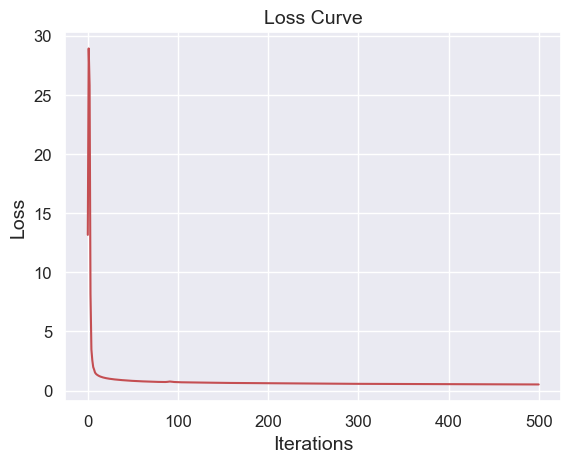

In [35]:
plt.plot(loss, linestyle='-', color='r')
plt.xlabel('Iterations', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Loss Curve', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.show()

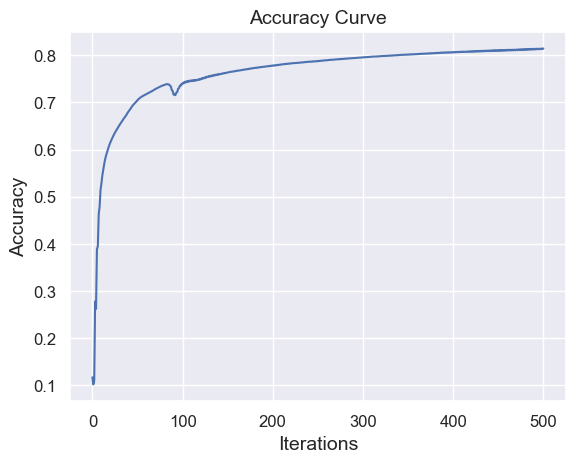

In [36]:
plt.plot(accuracy, linestyle='-', color='b')
plt.xlabel('Iterations', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Accuracy Curve', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.show()

In [37]:
cm = confusion_matrix(y_test, test_predictions)
print(cm)

[[759   7  10  70   1   5 127   0  21   0]
 [  5 951  11  16  10   0   6   0   1   0]
 [ 13   6 611  15 241   0 103   0  11   0]
 [ 41  29   4 843  42   3  26   0  12   0]
 [  1   4  42  22 841   0  84   0   6   0]
 [  3   0   1   1   0 872   1  74  16  32]
 [156   4  75  49 151   2 544   0  18   1]
 [  0   0   0   0   0  50   0 849   1 100]
 [  4   3  14   9   7  11  17   3 931   1]
 [  0   0   0   0   0  29   0  53   3 915]]


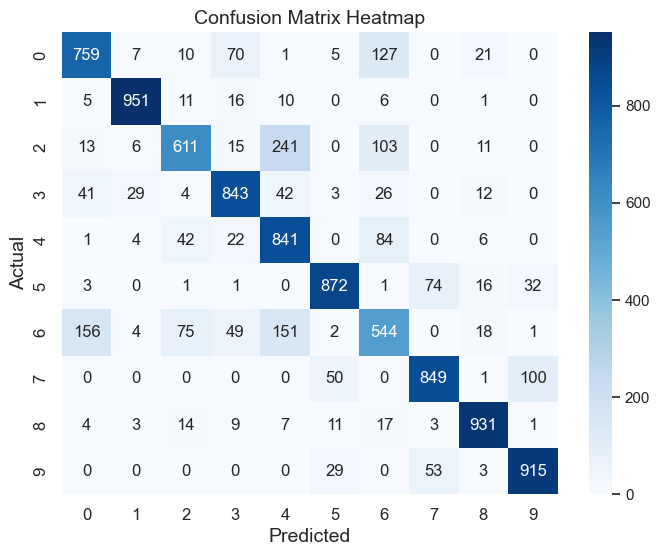

In [38]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.title('Confusion Matrix Heatmap', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [39]:
report = classification_report(y_test, test_predictions, zero_division=0)
print(report)

              precision    recall  f1-score   support

           0       0.77      0.76      0.77      1000
           1       0.95      0.95      0.95      1000
           2       0.80      0.61      0.69      1000
           3       0.82      0.84      0.83      1000
           4       0.65      0.84      0.73      1000
           5       0.90      0.87      0.88      1000
           6       0.60      0.54      0.57      1000
           7       0.87      0.85      0.86      1000
           8       0.91      0.93      0.92      1000
           9       0.87      0.92      0.89      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000

